In [1]:
import torch
from torch import nn
from torchmetrics.classification import MulticlassAccuracy
import tqdm
import numpy as np
import pandas as pd

In [2]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=False,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 458kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


In [3]:
image, label = test_dataset[0]
image.view(-1, 784).shape

torch.Size([1, 784])

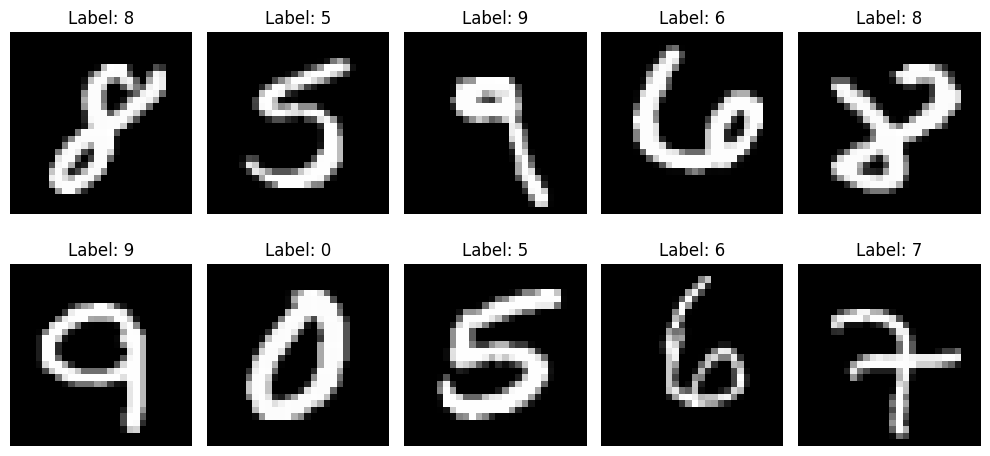

In [4]:
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax in axes.flat:
    index = random.randint(0, len(test_dataset) - 1)

    image, label = test_dataset[index]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
X_train = []
X_test = []
y_train = []
y_test = []

In [6]:
print("Adding data")
for image, label in tqdm.tqdm(train_dataset):
    X_train.append(image.view(-1, 784))
    y_train.append(label)

print("Done")

Adding data


100%|██████████| 60000/60000 [00:07<00:00, 8346.20it/s]

Done


In [7]:
print("Adding data")
for image, label in tqdm.tqdm(test_dataset):
    X_test.append(image.view(-1, 784))
    y_test.append(label)

print("Done")

Adding data


100%|██████████| 10000/10000 [00:01<00:00, 6169.81it/s]

Done


In [8]:
X_train = torch.stack(X_train)
y_train = torch.tensor(y_train)
X_test = torch.stack(X_test)
y_test = torch.tensor(y_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([60000, 1, 784]),
 torch.Size([60000]),
 torch.Size([10000, 1, 784]),
 torch.Size([10000]))

In [9]:
df = pd.DataFrame({"label": y_test})
df["label"].unique()

array([7, 2, 1, 0, 4, 9, 5, 6, 3, 8])

In [10]:
random_seed = 42
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [11]:
def plot_loss(epochs, train_loss, test_loss):
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, test_loss, label="Test loss")
    plt.title("Training and testing loss curves")
    plt.ylabel("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    plt.show()

In [56]:
hidden_layers = 20
neurons_per_hl = 256

In [294]:


class CharacterRecognitionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.layers(x)

torch.manual_seed(random_seed)

model = CharacterRecognitionModel()

In [295]:
model.to(device)
model

CharacterRecognitionModel(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [296]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1, momentum=0.9)
# optimizer = torch.optim.Adam(params=model.parameters(), lr=0.1)

# accuracy_fn = MulticlassAccuracy(num_classes=10).to(device)

In [297]:
epoch_count = []
train_loss_count = []
test_loss_count = []

In [298]:
X_train = X_train.squeeze()
X_test = X_test.squeeze()


X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([60000, 784]),
 torch.Size([60000]),
 torch.Size([10000, 784]),
 torch.Size([10000]))

In [299]:
epochs = 1000

# Fix: Ensure all tensors are on the correct device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    model.train()

    epoch_count.append(epoch)

    x_logits = model(X_train).squeeze()
    # print(x_logits.shape)
    x_preds = torch.softmax(x_logits, dim=1).argmax(dim=1)
    # print(x_preds.shape)

    train_loss = loss_fn(x_logits, y_train)
    train_loss_count.append(train_loss.cpu().detach().numpy())

    train_acc = (x_preds == y_train).float().mean()

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        y_logits = model(X_test).squeeze()
        y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(y_logits, y_test)
        test_loss_count.append(test_loss.cpu().detach().numpy())

        test_acc = (y_preds == y_test).float().mean()

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train_loss: {train_loss} | Train_acc: {train_acc} | Test_loss: {test_loss} | Test_acc: {test_acc}")

Epoch: 0 | Train_loss: 2.306664228439331 | Train_acc: 0.09915000200271606 | Test_loss: 2.305467128753662 | Test_acc: 0.10089999437332153
Epoch: 10 | Train_loss: 2.286317825317383 | Train_acc: 0.14603333175182343 | Test_loss: 2.2818760871887207 | Test_acc: 0.1744999885559082
Epoch: 20 | Train_loss: 2.2081706523895264 | Train_acc: 0.4786333441734314 | Test_loss: 2.1868438720703125 | Test_acc: 0.49289998412132263
Epoch: 30 | Train_loss: 1.6027657985687256 | Train_acc: 0.5372833609580994 | Test_loss: 1.4694676399230957 | Test_acc: 0.5575999617576599
Epoch: 40 | Train_loss: 0.7522075772285461 | Train_acc: 0.7645833492279053 | Test_loss: 0.8143182396888733 | Test_acc: 0.7188000082969666
Epoch: 50 | Train_loss: 1.6860929727554321 | Train_acc: 0.3839166760444641 | Test_loss: 1.612593173980713 | Test_acc: 0.4424999952316284
Epoch: 60 | Train_loss: 0.8763700723648071 | Train_acc: 0.6999666690826416 | Test_loss: 0.8102008700370789 | Test_acc: 0.774399995803833
Epoch: 70 | Train_loss: 0.5587543249

In [300]:
model.eval()
with torch.inference_mode():
    predictions = model(X_test).squeeze()

predictions.shape, (torch.softmax(predictions, dim=1).argmax(dim=1) == y_test)[:20]

(torch.Size([10000, 10]),
 tensor([ True,  True,  True,  True,  True,  True,  True,  True, False,  True,
          True,  True,  True,  True,  True,  True,  True,  True, False,  True],
        device='cuda:0'))

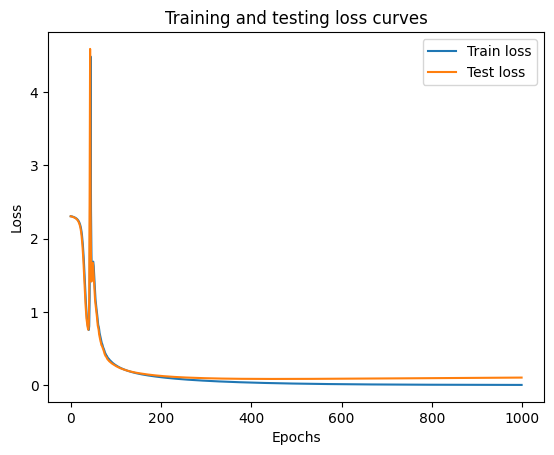

In [301]:
plot_loss(epoch_count, train_loss_count, test_loss_count)